# ReLU Activation Function. Vector Weights Norm Regularization.

In [1]:
# Check for all needed packages
import time

import IPython
import matplotlib
import mnists
import numpy

# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

try:
    import mkl

    mkl.set_num_threads(2)
except ImportError:
    print(
        "Intel Math Kernel Library (MKL) does not always work on every machine. "
        "Continuing without `mkl`."
    )

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [3]:
def append_ones(matrix: np.ndarray,  axis: int=1) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def randn(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a standard normal distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.randn(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def one_hot_encode(labels: np.ndarray) -> np.ndarray:
    """Convert integer labels to one-hot encoded matrix."""
    (n_samples,) = labels.shape
    n_classes = np.max(labels) + 1

    one_hot = np.zeros((n_samples, n_classes), dtype=np.float32)
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot

def classify(mlp: "MLP", batch: np.ndarray, forwad_pass_func: callable) -> np.ndarray:
    """
    Classify a batch of inputs using the MLP model.
    
    Performs a forward pass to compute class probabilities, then returns
    the predicted class indices (argmax over probabilities).
    
    Args:
        mlp: Trained MLP model with forward_pass method.
        batch: Input data batch of shape (N, input_dim).
    
    Returns:
        Predicted class indices of shape (N,).
    """
    # Shape: (batch_size, num_classes)
    probabilities: np.ndarray = forwad_pass_func(mlp, batch, False)
    
    predictions = np.argmax(probabilities, axis=1)
    return predictions

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def preview_tiles(examples: np.ndarray) -> None:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()

def draw_rbm_filters(rbm: "RestrictedBoltzmannMachine") -> None:
    filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], shape=(8, -1, 28, 28))
    preview_tiles(filters)

def draw_layer_filters(layer: "Layer") -> None:
    filters = np.reshape(layer.W[:-1].T, shape=(8, -1, 28, 28))
    preview_tiles(filters)

### Activation functions

In [ ]:
def sigmoid(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    activations = 1.0 / (1.0 + np.exp(-batch))
    if stochastic:
        return activations > rand(*activations.shape).astype(np.float32)
    else:
        return activations

def sigmoid_derivative(batch):
    s = sigmoid(batch)
    return s * (1.0 - s)

def softmax(batch: np.ndarray) -> np.ndarray:
    # TODO implement
    raise Exception('Softmax activation function is not implemented!')


# MNIST dataset

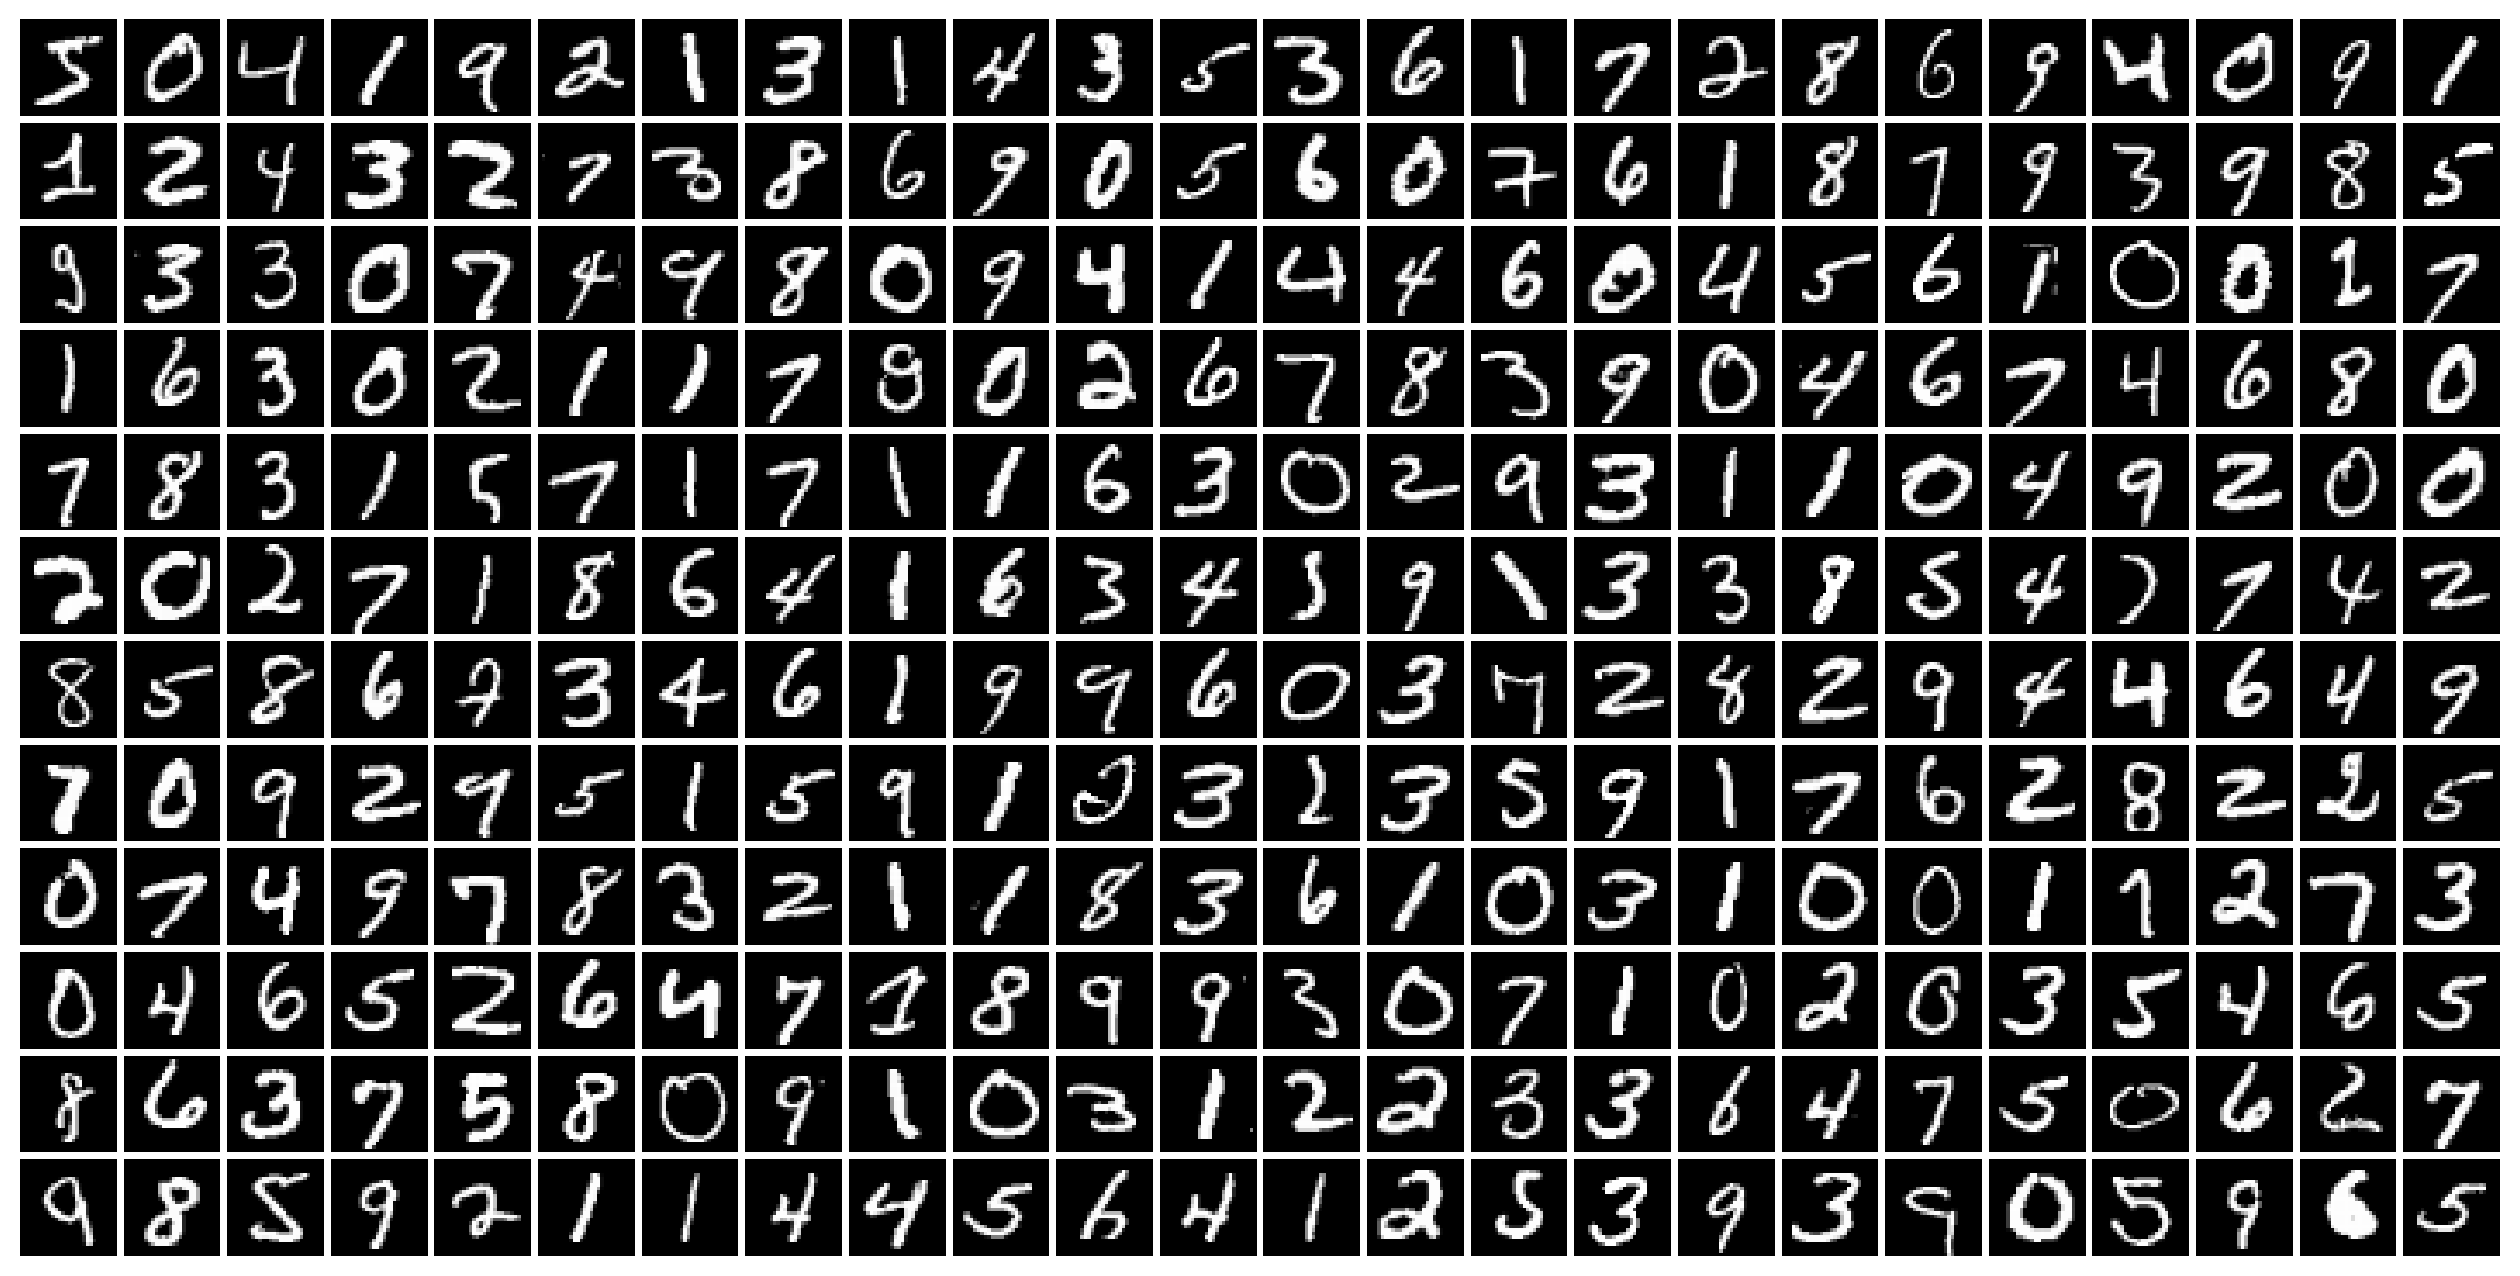

In [5]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]


def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], shape=shape)


mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# ReLU and Max-Norm regularization

Stochastic ReLU: $ f(z) = z \cdot \mathbb{1}_{z>0} + \epsilon $

Standard: $ f(z) = \max(0, z) $

Stochastic: $ f(z) = z + \mathcal{N}(0, \sigma(z)) $

where $ \sigma(z) = \sqrt{sigmoid(z)} $



ReLU derivative: $ f'(z) = \mathbb{1}_{z>0} $

In [ ]:
def relu(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    """
    Stochastic ReLU
    """
    # TODO implement
    raise Exception("Not implemented!")

def relu_derivative(batch: np.ndarray) -> np.ndarray:
    """
    ReLU derivative
    """
    # TODO implement
    raise Exception("Not implemented!")

Weight normalization: $ W_{norm} = W / \max(1, ||W_{:,j}||/\lambda) $

Ensures $ ||W_{norm_{:,j}}||_2 \leq \lambda $ for each column $ j $

In [ ]:
def limit_weights(weights: np.ndarray, lambda_limit: float) -> np.ndarray:
    """
    Weight normalization
    """
    
    # TODO implement
    raise Exception("Not implemented!")

# RBM & DBN training

In [8]:
class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:       Number of visible (input) units, excluding the bias.
        hidden_size:        Number of hidden units, excluding the bias.
        visible_act_func:   The activation function used within visible layer.
        hidden_act_func:    The activation function used within hidden layer.
        learning_rate:      Step size used during contrastive divergence updates.
        W:                  Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:           Momentum coefficient.
        weight_limit:       Weight limit normalization coefficient.
    """
    
    def __init__(
        self, 
        visible_size: int,
        hidden_size: int,
        visible_act_func: callable, 
        hidden_act_func: callable, 
        learning_rate: float,
        momentum: float,
        weight_limit: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        
        self.visible_act_func = visible_act_func
        self.hidden_act_func = hidden_act_func
        
        self.learning_rate = learning_rate
        self.momentum = momentum
        
        self.weight_limit = weight_limit
        
        self.reset()
    
    def reset(self) -> None:
        self.W = np.random.normal(scale=0.01, size=(self.visible_size+1, self.hidden_size+1)).astype(np.float32)
        self.W[:, -1] = 0.0  # zero hidden-bias weights
        self.W[-1, :] = 0.0  # zero visible-bias weights
        self.M = zeros(self.visible_size+1, self.hidden_size+1)

In [9]:
from typing import TypeAlias
DBN: TypeAlias = list[RestrictedBoltzmannMachine]

In [10]:
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    positive_hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
    negative_hidden[:, :-1] = (
        positive_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)
    ).astype(np.float32)

    for cd_i in range(k):
        negative_visible[:, :-1] = sigmoid(
            negative_hidden @ np.transpose(rbm.W[:-1, :])
        )
        negative_visible[:, :-1] = (
            negative_visible[:, :-1] > rand(observations_count, rbm.visible_size)
        ).astype(float)

        negative_hidden[:, :-1] = sigmoid(negative_visible @ rbm.W[:, :-1])
        if cd_i < (k - 1):
            negative_hidden[:, :-1] = (
                negative_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)
            ).astype(np.float32)

    rbm.M = (
        rbm.momentum * rbm.M
        + (rbm.learning_rate / observations_count)
        * (np.transpose(positive_visible) @ positive_hidden)
        - (rbm.learning_rate / observations_count)
        * (np.transpose(negative_visible) @ negative_hidden)
    )

    rbm.W = rbm.W + rbm.M

def reconstruction_error(
    rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray
) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.
    """

    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    
    hidden[:, :-1] =  rbm.hidden_act_func(minibatch @ rbm.W[:, :-1], stochastic=True)
    visible = rbm.visible_act_func(hidden @ np.transpose(rbm.W[:-1, :]))
    
    error = minibatch[:, :-1] - visible
    return np.sum(np.square(error)) / observations_count

In [11]:
def propagate_up(
    dbn: DBN,
    layers_count: int,
    visible: np.ndarray,
) -> np.ndarray:
    """
    Forward pass through DBN layers: propagates visible units upward to the target layer.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in range(layers_count):
        visible = append_ones(sigmoid(visible @ dbn[i].W[:, :-1]))
    return visible


def propagate_down(
    dbn: DBN,
    layers_count: int,
    hidden: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct data by propagating downward through the DBN.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in reversed(range(layers_count)):
        hidden = append_ones(sigmoid(hidden @ np.transpose(dbn[i].W[:-1, :])))
    return hidden

def dbn_reconstuction_error(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
) -> float:
    """
    Compute the reconstruction error for a selected DBN layer.

    The minibatch is first propagated upward to the chosen layer,
    then the reconstruction error is evaluated for that RBM.

    Args:
        dbn: List of pretrained RBM layers.
        layer_idx: Index of the RBM layer to evaluate.
        minibatch: Input minibatch.

    Returns:
        Reconstruction error as a scalar value.
    """
    propagated = propagate_up(dbn, layer_idx, minibatch)
    error = reconstruction_error(dbn[layer_idx], propagated)

    return error

def train_dbn_layer(
    dbn: DBN,
    layer_idx: int,
    dataset: np.ndarray,
    batch_size: int,
) -> None:
    """
    Train one DBN layer using greedy layer-wise pretraining.

    The dataset is first propagated through all previously trained layers.
    Then the selected RBM layer is trained on minibatches.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the RBM layer to train.
        dataset: Full training dataset.
        batch_size: Minibatch size.
    """

    dataset = propagate_up(dbn, layer_idx, dataset)

    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")

def run_dbn_training(
    dbn: DBN,
    dataset: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
    target_momentum: float = 0.9,
) -> None:
    for layer_idx in range(len(dbn)):
        print(f"\nLearning layer {layer_idx}")

        for epoch in range(epochs_count):
            print(f"Epoch {epoch}:", end="\t")

            if epoch == 5:
                dbn[layer_idx].momentum = target_momentum

            start_time = time.time()
            train_dbn_layer(dbn, layer_idx, dataset, batch_size)
            elapsed = time.time() - start_time

            error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
            print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

# MLP training

In [12]:
class Layer:
    def __init__(
        self, 
        visible_size: int,
        hidden_size: int,
        activation_fun: callable[np.ndarray],
        d_activation_fun: callable[np.ndarray],
        learning_rate: float,
        momentum: float,
        weight_limit: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        
        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun
                
        self.learning_rate = learning_rate
        self.momentum = momentum
        
        self.weight_limit = weight_limit
        
        self.reset()
    
    def reset(self) -> None:
        self.W = np.random.normal(scale=0.01, size=(self.visible_size+1, self.hidden_size)).astype(np.float32)
        self.W[-1, :] = 0.0
        
        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size+1, self.hidden_size)

In [13]:
from typing import TypeAlias
MLP: TypeAlias = list[Layer]

### Forward pass

In [ ]:
def forward_pass(mlp: MLP, batch: np.ndarray, compute_derivatives: bool) -> np.ndarray:
    visible = batch

    for layer_idx, layer in enumerate(mlp):
        # TODO implement
        raise Exception("Compute layer activations here!")
        # z = ???
        # layer.activations = ???
        
        if compute_derivatives and (layer_idx < len(mlp) - 1):
            # TODO implement
            raise Exception("Remember about the derivatives of the activation function!")
            # layer.d_activations = ???
            
        visible = layer.activations
    
    return visible[:, :-1]

### Error backpropagation

In [ ]:
def error_backpropagate(mlp: MLP, batch: np.ndarray) -> None:
    observations_count = batch.shape[0]

    for layer_idx, layer in reversed(list(enumerate(mlp))):
        if layer_idx > 0:
            prev_layer = mlp[layer_idx - 1]
            visible = prev_layer.activations
            
            # TODO implement
            raise Exception("Calculate the deltas in 'prev_layer'")
            # prev_layer.deltas = ???
            
        else:
            visible = batch
        
        # TODO implement
        raise Exception("Update the momentum matrix with gradient from error backpropagation")
        # layer.M = ???
        
        if layer.weight_limit > 0.0:
            layer.W[:-1, :] = limit_weights(layer.W[:-1, :], layer.weight_limit)

### Training procedure

In [ ]:
def train_mlp(
    mlp: MLP, dataset: np.ndarray, labels: np.ndarray, batch_size: np.ndarray
) -> None:
    batches_limit = dataset.shape[0] / batch_size
    
    batched_data = chunks(dataset, batch_size)
    batched_labels = chunks(labels, batch_size)
    
    for batch_idx, (batch, batch_labels) in enumerate(zip(batched_data, batched_labels)):
        # Forward pass: compute activatations and derivatives of activations
        y = forward_pass(mlp, batch, True)
        
        # TODO implement
        raise Exception("Delta in the sofmax layer is unimplemented!")
        # mlp[-1].deltas = ???
        
        # Once softmax deltas are set, we may backpropagate errors
        error_backpropagate(mlp, batch)
        
        if batch_idx % round(batches_limit / 40) == 0: print("#", end="")

In [17]:
def run_mlp_training(
    mlp: MLP,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    batch_size: int,
    epochs_count: int,
    forward_pass_func: callable,
    target_momentum: float = 0.95,
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch + 1}:", end="\t")
        
        if epoch == 5:
            for layer in mlp: layer.momentum = target_momentum

        start_time = time.time()
        train_mlp(mlp, train_set, train_labels, batch_size)
        elapsed = time.time() - start_time

        predictions = classify(mlp, validation_set, forward_pass_func)
        accuracy = (
            100.0 * np.sum(predictions == validation_labels) / predictions.shape[0]
        )
        print(f"\telapsed: {elapsed:>2.2f}s, accuracy: {accuracy:>2.2f}")
    print("Training finished!")
    

#  Initializing MLP with DBN weights

Implement initialization of MLP weights (and biases) using weights (and biases) from the DBN layers.

Make sure that the MLP weights (and biases) are **copies** of the DBN weights (and biases). You can use ```np.copy(...)``` function to copy the weights (simple assignment will make a view instead of a copy).

In [ ]:
def initialize_mlp_from_dbn(mlp: MLP, dbn: DBN) -> None:
    # Protip for better encpaulsation: create a helper class for MLP, with a custom constructor (@classmethod), `from_dbn(dbn: DBN)`
    
    # TODO implement
    raise Exception('Initialization of MLP from a pre-trained network is unimplemented')

# MNIST digits classification

In [19]:
np.random.seed(1234)

DATASET_SIZE: int = 10000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_labels = mnist.train_labels()

order = np.random.permutation(len(mnist_train_images))
mnist_train_images = mnist_train_images[order]
mnist_train_labels = mnist_train_labels[order]

mnist_train_images = np.reshape(mnist_train_images[:DATASET_SIZE],
                                shape=(DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
mnist_train_images = append_ones(mnist_train_images)

mnist_train_labels = mnist_train_labels[:DATASET_SIZE]
mnist_train_labels = one_hot_encode(mnist_train_labels)

monitoring_set_indeces = np.random.choice(mnist_train_images.shape[0], 512, replace=False)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(mnist_test_images, shape=(-1, DIGIT_SIZE*DIGIT_SIZE))
mnist_test_images = append_ones(mnist_test_images)

mnist_test_labels = mnist.test_labels()

In [20]:
VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 256

BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

MLP_LEARNING_RATE: float = 0.03
SOFTMAX_LEARNING_RATE: float = 0.15
RBM_LEARNING_RATE: float = 0.003
MOMENTUM: float = 0.5

### Plain vs pretrained comparison

In [21]:
from IPython.core.display import HTML


def compare_pretraining_results(
    mlp: MLP,
    dbn: DBN,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for layer in mlp:
        layer.reset()

    display(HTML("<h3>Plain MLP training</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
        forward_pass_func=forward_pass,
    )

    display(HTML("<h3>Input layer filters in the plain MLP</h3>"))
    draw_layer_filters(mlp[0])

    display(HTML("<h3>DBN training</h3>"))
    run_dbn_training(
        dbn=dbn,
        dataset=train_set,
        monitoring_set=monitoring_set,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    for layer in mlp:
        layer.reset()

    initialize_mlp_from_dbn(mlp, dbn)

    display(HTML("<h3>Finetuning pretrained MLP</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
        forward_pass_func=forward_pass,
    )

    display(HTML("<h3>First layer filters in the DBN</h3>"))
    draw_rbm_filters(dbn[0])

    display(HTML("<h3>Input layer filters in the pretrained & finetuned MLP</h3>"))
    draw_layer_filters(mlp[0])

### Shallow ReLU network

Epoch 1:	########################################	elapsed: 0.59s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 0.52s, accuracy: 31.54
Epoch 3:	########################################	elapsed: 0.43s, accuracy: 65.26
Epoch 4:	########################################	elapsed: 0.49s, accuracy: 74.15
Epoch 5:	########################################	elapsed: 0.33s, accuracy: 80.37
Epoch 6:	########################################	elapsed: 0.35s, accuracy: 89.83
Epoch 7:	########################################	elapsed: 0.36s, accuracy: 92.37
Epoch 8:	########################################	elapsed: 0.32s, accuracy: 93.20
Epoch 9:	########################################	elapsed: 0.36s, accuracy: 94.36
Epoch 10:	########################################	elapsed: 0.37s, accuracy: 93.53
Epoch 11:	########################################	elapsed: 0.33s, accuracy: 93.94
Epoch 12:	########################################	elapsed: 0.49s, accuracy: 94.71
Epoch 13:	###

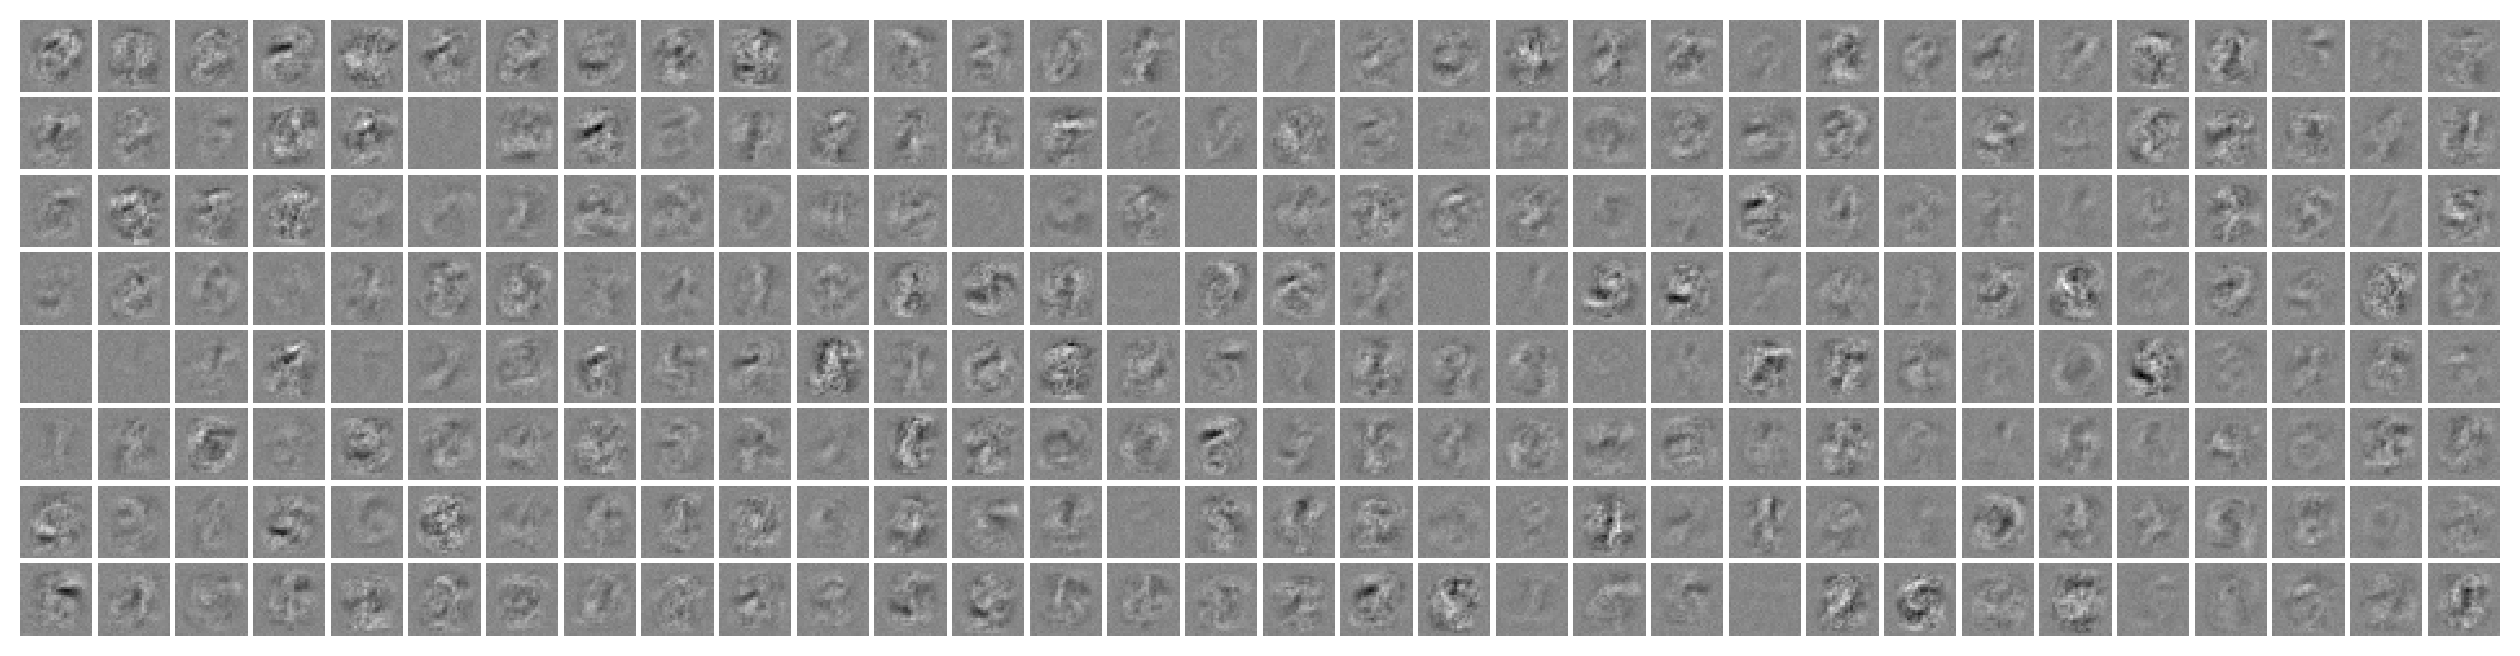


Learning layer 0
Epoch 0:	########################################	elapsed: 1.05s, reconstruction error: 75.99
Epoch 1:	########################################	elapsed: 0.87s, reconstruction error: 73.91
Epoch 2:	########################################	elapsed: 0.56s, reconstruction error: 71.46
Epoch 3:	########################################	elapsed: 0.55s, reconstruction error: 67.33
Epoch 4:	########################################	elapsed: 0.61s, reconstruction error: 61.13
Epoch 5:	########################################	elapsed: 0.60s, reconstruction error: 44.40
Epoch 6:	########################################	elapsed: 0.83s, reconstruction error: 41.52
Epoch 7:	########################################	elapsed: 0.62s, reconstruction error: 40.08
Epoch 8:	########################################	elapsed: 0.65s, reconstruction error: 39.34
Epoch 9:	########################################	elapsed: 0.64s, reconstruction error: 37.92
Epoch 10:	################################

Epoch 1:	########################################	elapsed: 0.58s, accuracy: 93.11
Epoch 2:	########################################	elapsed: 0.41s, accuracy: 94.67
Epoch 3:	########################################	elapsed: 1.52s, accuracy: 95.47
Epoch 4:	########################################	elapsed: 0.58s, accuracy: 95.75
Epoch 5:	########################################	elapsed: 0.33s, accuracy: 96.17
Epoch 6:	########################################	elapsed: 0.44s, accuracy: 96.37
Epoch 7:	########################################	elapsed: 0.34s, accuracy: 96.42
Epoch 8:	########################################	elapsed: 0.37s, accuracy: 96.39
Epoch 9:	########################################	elapsed: 0.36s, accuracy: 96.55
Epoch 10:	########################################	elapsed: 0.44s, accuracy: 96.64
Epoch 11:	########################################	elapsed: 0.60s, accuracy: 96.79
Epoch 12:	########################################	elapsed: 0.44s, accuracy: 96.86
Epoch 13:	###

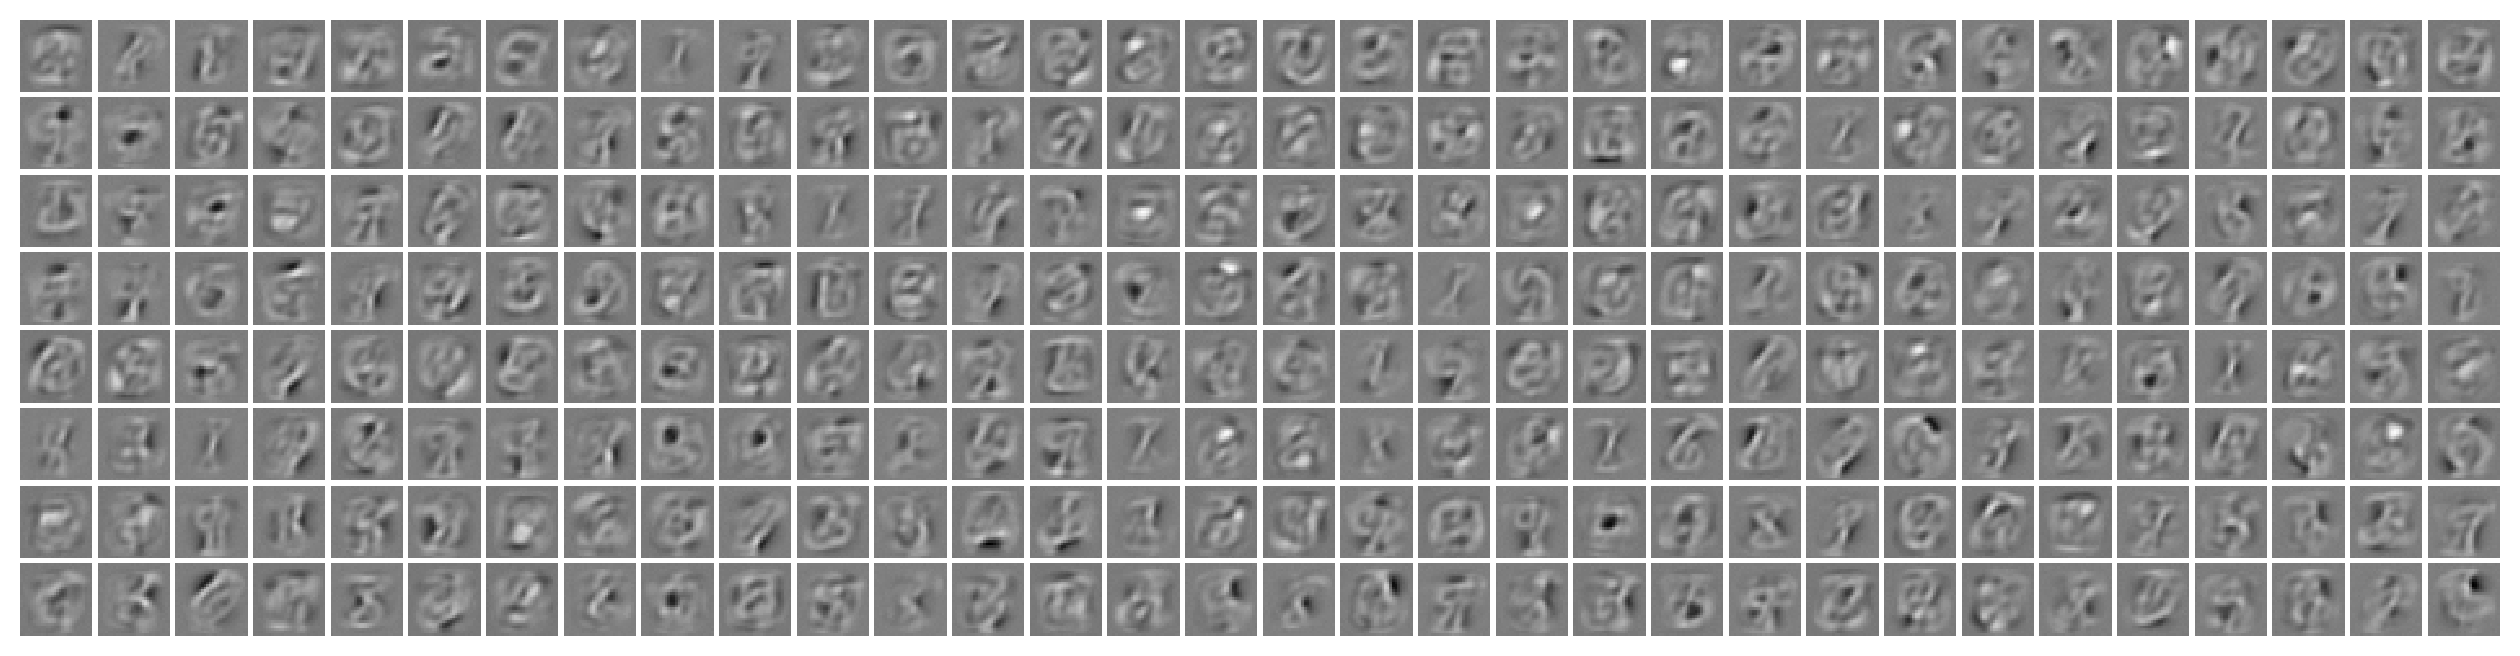

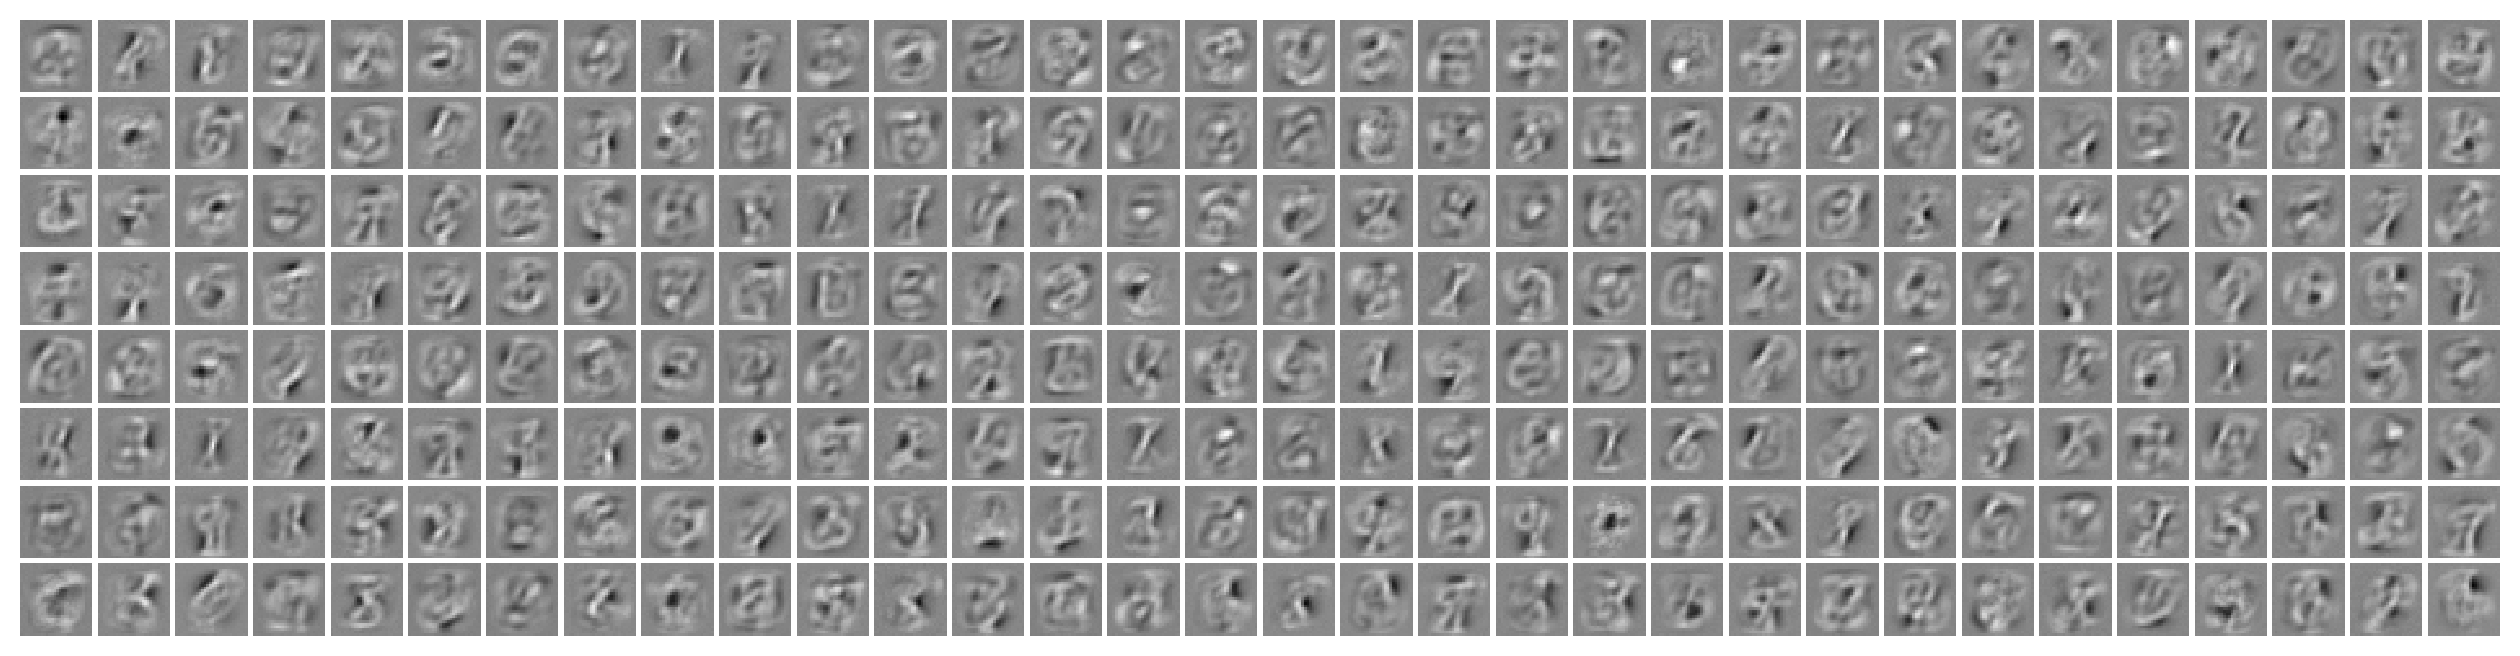

In [22]:
shallow_mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        learning_rate=SOFTMAX_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=4.0,
    ),
]

shallow_dbn = [
    RestrictedBoltzmannMachine(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=sigmoid,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    RestrictedBoltzmannMachine(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=relu,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    )
]

compare_pretraining_results(
    mlp=shallow_mlp,
    dbn=shallow_dbn,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

### Deep ReLU network

Epoch 1:	########################################	elapsed: 1.07s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 0.58s, accuracy: 11.35
Epoch 3:	########################################	elapsed: 0.70s, accuracy: 11.35
Epoch 4:	########################################	elapsed: 0.52s, accuracy: 11.35
Epoch 5:	########################################	elapsed: 0.86s, accuracy: 11.35
Epoch 6:	########################################	elapsed: 0.85s, accuracy: 44.20
Epoch 7:	########################################	elapsed: 0.66s, accuracy: 83.47
Epoch 8:	########################################	elapsed: 0.60s, accuracy: 90.42
Epoch 9:	########################################	elapsed: 0.61s, accuracy: 92.15
Epoch 10:	########################################	elapsed: 0.55s, accuracy: 93.18
Epoch 11:	########################################	elapsed: 0.60s, accuracy: 93.52
Epoch 12:	########################################	elapsed: 2.12s, accuracy: 92.93
Epoch 13:	###

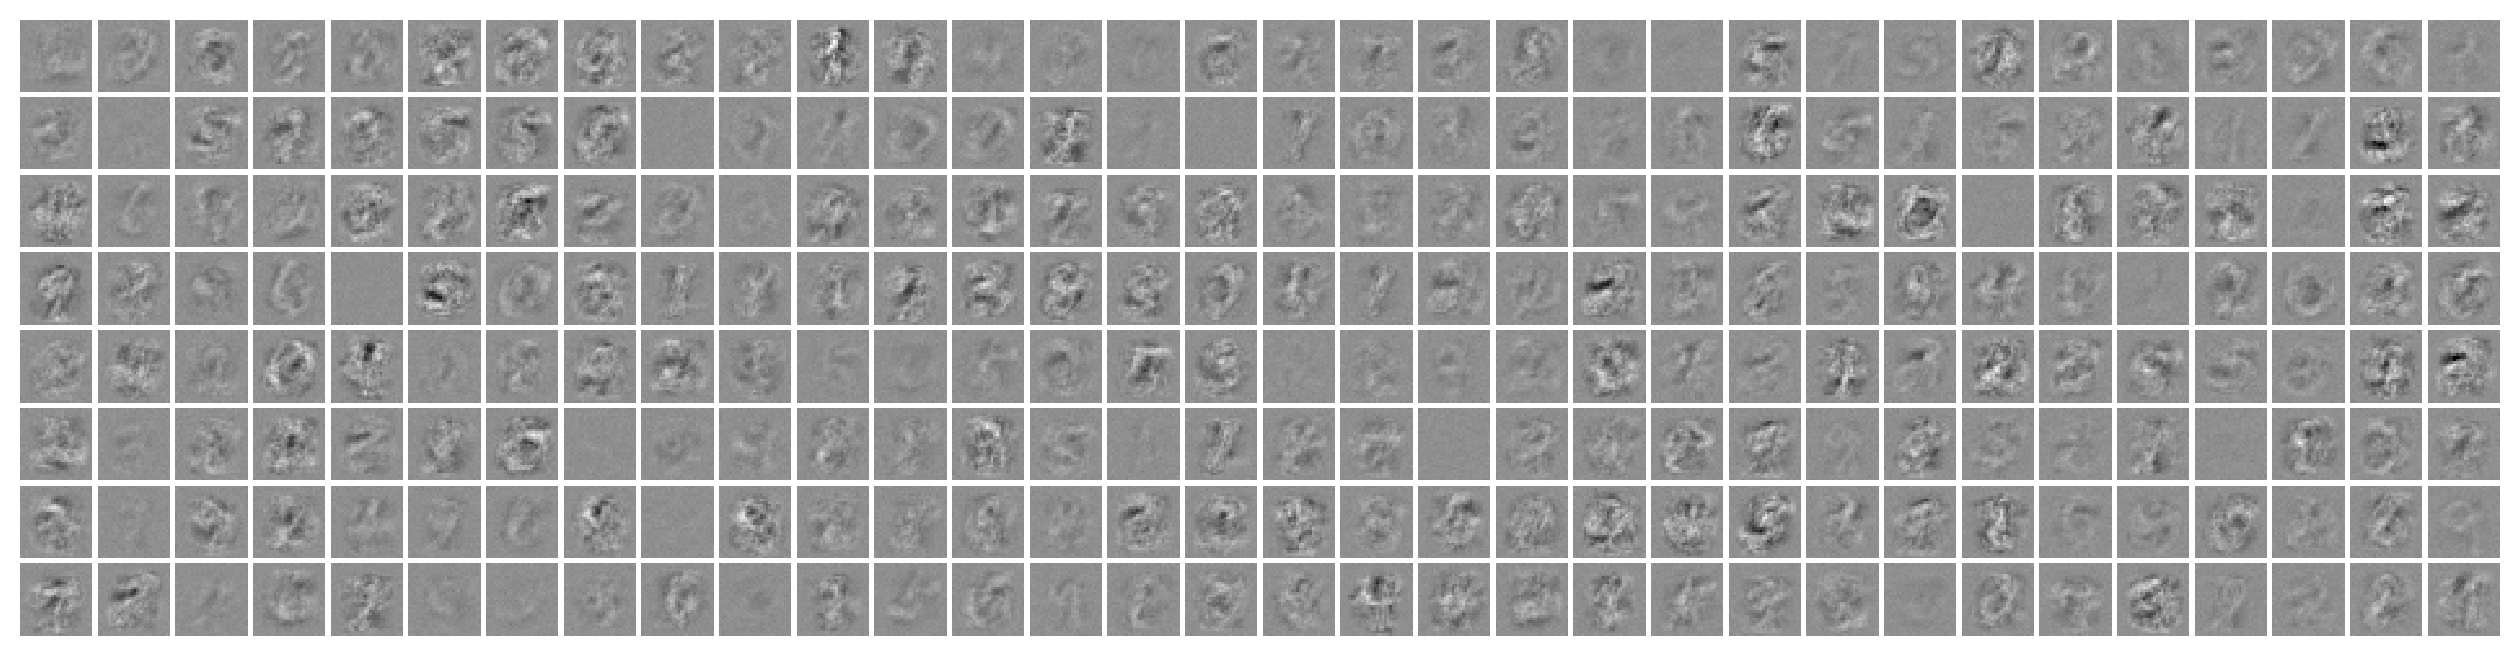


Learning layer 0
Epoch 0:	########################################	elapsed: 1.07s, reconstruction error: 75.38
Epoch 1:	########################################	elapsed: 0.70s, reconstruction error: 73.85
Epoch 2:	########################################	elapsed: 0.63s, reconstruction error: 71.34
Epoch 3:	########################################	elapsed: 0.76s, reconstruction error: 67.71
Epoch 4:	########################################	elapsed: 0.68s, reconstruction error: 61.90
Epoch 5:	########################################	elapsed: 1.04s, reconstruction error: 44.50
Epoch 6:	########################################	elapsed: 0.76s, reconstruction error: 41.10
Epoch 7:	########################################	elapsed: 0.78s, reconstruction error: 39.92
Epoch 8:	########################################	elapsed: 0.78s, reconstruction error: 38.83
Epoch 9:	########################################	elapsed: 0.76s, reconstruction error: 37.51
Epoch 10:	################################

Epoch 1:	########################################	elapsed: 1.02s, accuracy: 91.47
Epoch 2:	########################################	elapsed: 0.64s, accuracy: 93.71
Epoch 3:	########################################	elapsed: 0.72s, accuracy: 93.77
Epoch 4:	########################################	elapsed: 0.60s, accuracy: 94.07
Epoch 5:	########################################	elapsed: 0.59s, accuracy: 94.88
Epoch 6:	########################################	elapsed: 0.54s, accuracy: 94.72
Epoch 7:	########################################	elapsed: 0.57s, accuracy: 95.24
Epoch 8:	########################################	elapsed: 0.59s, accuracy: 95.00
Epoch 9:	########################################	elapsed: 0.60s, accuracy: 94.69
Epoch 10:	########################################	elapsed: 0.59s, accuracy: 95.22
Epoch 11:	########################################	elapsed: 0.59s, accuracy: 95.59
Epoch 12:	########################################	elapsed: 0.57s, accuracy: 95.38
Epoch 13:	###

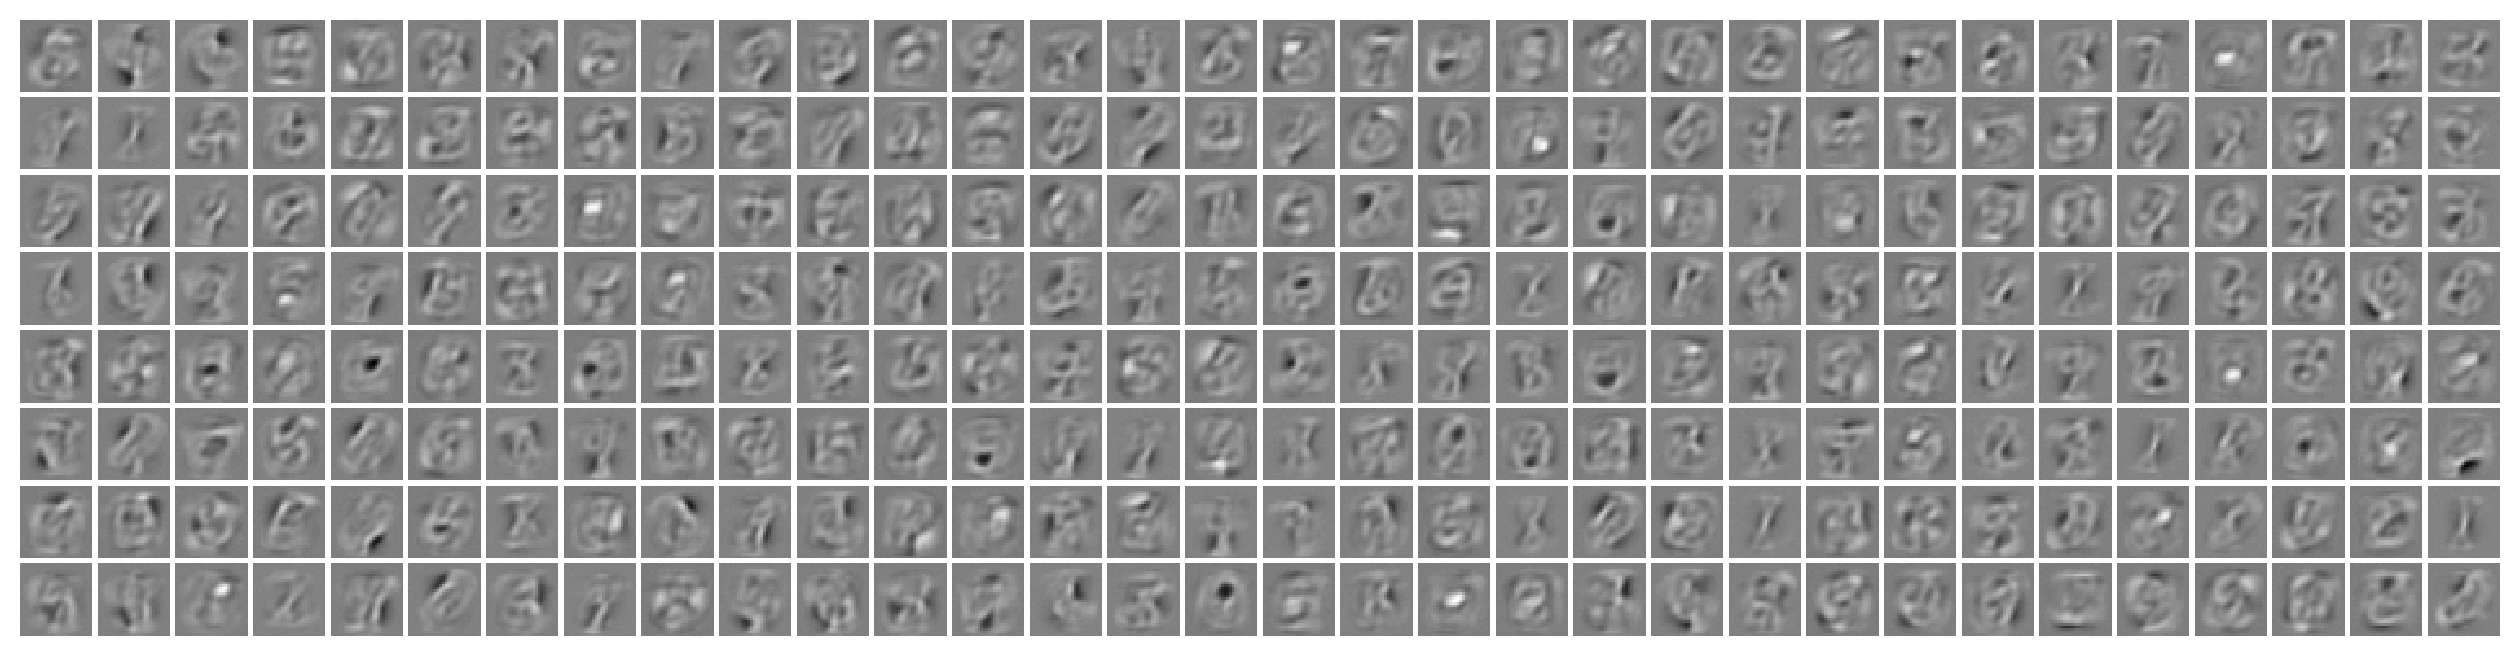

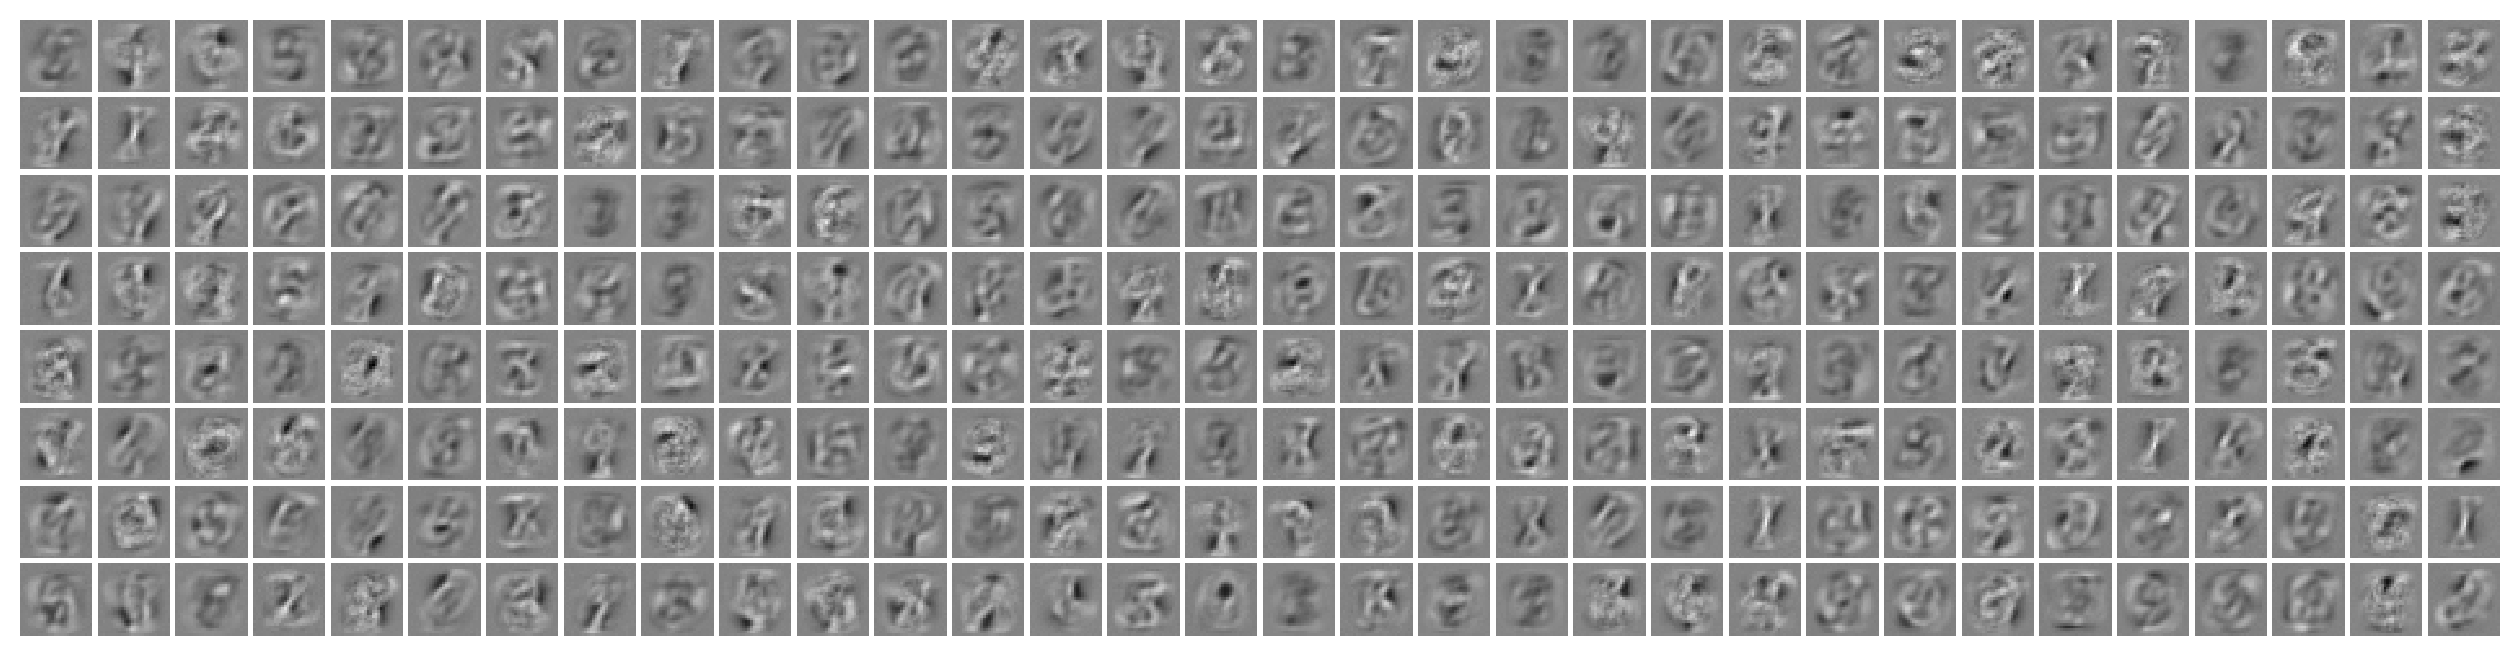

In [23]:
deep_mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=2 * HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=2 * HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        learning_rate=SOFTMAX_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=4.0,
    ),
]

deep_dbn = [
    RestrictedBoltzmannMachine(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=sigmoid,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    RestrictedBoltzmannMachine(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=relu,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    RestrictedBoltzmannMachine(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=2 * HIDDEN_LAYER_SIZE,
        visible_act_func=relu,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    )
]

compare_pretraining_results(
    mlp=deep_mlp,
    dbn=deep_dbn,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)